# Exploratory Data Analysis — what the data says before any model

This notebook interrogates the raw FastF1 lap/weather data *before* modelling, and it is
deliberately opinionated: every figure answers one question, and the findings at the end are the
ones that shaped the modelling decisions documented in [methodology.md](../docs/methodology.md).

It needs **no trained models and no network** — the six merged race files ship with the repository,
so this runs in seconds on a fresh clone.

**The seven questions**

1. How many laps do we actually get to model, and what removes the rest?
2. Forty raw columns, eleven features — why can't the rest be used?
3. What does the target look like, and what does its shape imply for achievable accuracy?
4. Is there a degradation signal in the data at all?
5. What ranges of wind and temperature were actually observed — and do the test races fall inside them?
6. Are the control features confounded with each other?
7. Is the data clean where it matters, and how finely is weather really sampled?

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from f1lab import TempPreprocessor, WindPreprocessor

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
WIND_C, TEMP_C = "tab:blue", "tab:red"

RACES = {
    "Baku 22-24 (wind train)":      ("2022-2024_Azerbaijan_Grand_Prix.xlsx", WindPreprocessor),
    "Baku 25 (wind in-domain)":     ("2025_Azerbaijan_Grand_Prix.xlsx",      WindPreprocessor),
    "Jeddah 25 (wind cross)":       ("2025_Saudi_Arabian_Grand_Prix.xlsx",   WindPreprocessor),
    "Singapore 22-24 (temp train)": ("2022-2024_Singapore_Grand_Prix.xlsx",  TempPreprocessor),
    "Singapore 25 (temp in-dom.)":  ("2025_Singapore_Grand_Prix.xlsx",       TempPreprocessor),
    "Vegas 25 (temp cross)":        ("2025_Las_Vegas_Grand_Prix.xlsx",       TempPreprocessor),
}

raw, modelled = {}, {}
for label, (fname, cls) in RACES.items():
    path = PROJECT_ROOT / "data" / "merged" / fname
    raw[label] = pd.read_excel(path)
    df, x, y = cls.from_excel(str(path)).run()
    modelled[label] = {"df": df, "x": x, "y": y}

print(f"{len(raw)} race files loaded (no models, no network)")
print(f"raw columns: {raw['Baku 22-24 (wind train)'].shape[1]}")
for label in RACES:
    print(f"  {label:30s} raw {len(raw[label]):5d} laps -> modelled {len(modelled[label]['x']):5d}")

6 race files loaded (no models, no network)
raw columns: 40
  Baku 22-24 (wind train)        raw  2826 laps -> modelled  2248
  Baku 25 (wind in-domain)       raw   968 laps -> modelled   725
  Jeddah 25 (wind cross)         raw   898 laps -> modelled   776
  Singapore 22-24 (temp train)   raw  3210 laps -> modelled  2366
  Singapore 25 (temp in-dom.)    raw  1229 laps -> modelled  1080
  Vegas 25 (temp cross)          raw   886 laps -> modelled   712


## Q1 — How many laps survive, and what removes the rest?

The pipeline drops pit-in/pit-out laps, non-green-flag laps (`TrackStatus != '1'`), and the lap
immediately following either, because those laps reflect traffic, safety-car pace or cold tyres
rather than the mechanisms under study. A few more rows go with a missing `LapTime` or a
non-positive normalised tyre life. Reproducing that accounting here shows what each rule costs.

In [2]:
rows = []
for label, df0 in raw.items():
    df = df0.sort_values(["RaceYear", "GPName", "Driver", "LapNumber"]).copy()
    df[["PitInTime", "PitOutTime"]] = df[["PitInTime", "PitOutTime"]].replace("", np.nan)
    is_pit = df["PitInTime"].notna() | df["PitOutTime"].notna()
    not_green = df["TrackStatus"].astype(str) != "1"
    invalid = is_pit | not_green
    prev_invalid = (
        invalid.groupby([df["RaceYear"], df["GPName"], df["Driver"]])
        .shift(1).fillna(False).astype(bool)
    )
    survived_filter = int((~(invalid | prev_invalid)).sum())
    n_model = len(modelled[label]["x"])
    rows.append({
        "race": label,
        "raw laps": len(df),
        "pit laps": int(is_pit.sum()),
        "non-green": int((not_green & ~is_pit).sum()),
        "lap after invalid": int((prev_invalid & ~invalid).sum()),
        "other (no LapTime etc.)": survived_filter - n_model,
        "modelled": n_model,
    })

attrition = pd.DataFrame(rows).set_index("race")
attrition["dropped %"] = (100 * (1 - attrition["modelled"] / attrition["raw laps"])).round(1)
attrition

,raw laps,pit laps,non-green,lap after invalid,other (no LapTime etc.),modelled,dropped %
race,,,,,,,
Baku 22-24 (wind train),2826,154,240,180,4,2248,20.5
Baku 25 (wind in-domain),968,41,131,71,0,725,25.1
Jeddah 25 (wind cross),898,39,49,34,0,776,13.6
Singapore 22-24 (temp train),3210,144,479,220,1,2366,26.3
Singapore 25 (temp in-dom.),1229,48,39,62,0,1080,12.1
Vegas 25 (temp cross),886,45,81,48,0,712,19.6


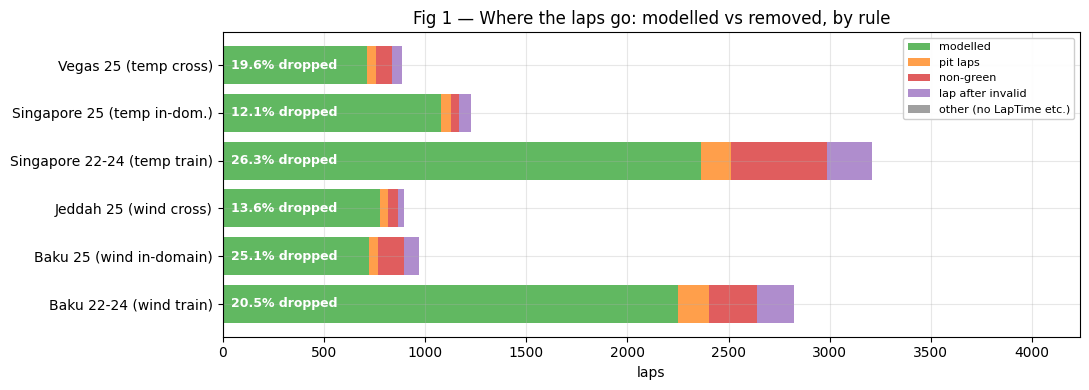

In [3]:
causes = ["pit laps", "non-green", "lap after invalid", "other (no LapTime etc.)"]
fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(attrition))
ax.barh(attrition.index, attrition["modelled"], color="tab:green", alpha=0.75, label="modelled")
bottom += attrition["modelled"].values
for cause, colour in zip(causes, ["tab:orange", "tab:red", "tab:purple", "grey"]):
    ax.barh(attrition.index, attrition[cause], left=bottom, color=colour, alpha=0.75, label=cause)
    bottom += attrition[cause].values
for i, (_, r) in enumerate(attrition.iterrows()):
    ax.text(40, i, f"{r['dropped %']}% dropped", va="center", fontsize=9,
            color="white", fontweight="bold")
ax.set_xlabel("laps")
ax.set_title("Fig 1 — Where the laps go: modelled vs removed, by rule")
ax.legend(loc="upper right", fontsize=8, framealpha=0.95)
ax.set_xlim(0, attrition["raw laps"].max() * 1.32)
plt.tight_layout()
plt.show()

**Reading it.** Attrition ranges from 12% to 26%, and it tracks the individual race rather than the
circuit: Singapore's 2022-24 training races lose 26.3% of their laps while Singapore 2025 loses only
12.1%, and Baku swings from 20.5% to 25.1% between its training years and 2025. Safety cars and
red flags — not track layout — drive the difference. Two consequences worth carrying forward: the
temperature study is fitted on proportionally less clean data than the wind study (26.3% vs 20.5%
attrition), and the non-green rule removes far more laps than pit stops do, so the filter is mostly
about race interruptions rather than pit cycles.

## Q2 — Forty raw columns, eleven features: why the rest can't be used

The merged files carry 40 columns. Most are dropped for mundane reasons (identifiers, timestamps,
almost-always-empty flags), but one group is dropped for a substantive one: **the three sector times
sum to the lap time**, so feeding them to a model predicting a lap-time-derived target would leak
the answer into the inputs. That claim is easy to test rather than assert.

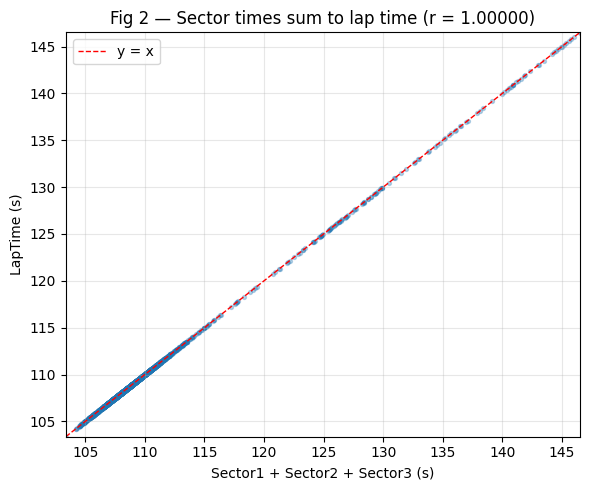

correlation                       : 1.000000
median |sum(sectors) - LapTime|   : 1.0 ms
laps agreeing within 1 s          : 100.0%


In [4]:
d = raw["Baku 22-24 (wind train)"]
secs = sum(pd.to_timedelta(d[f"Sector{i}Time"], errors="coerce").dt.total_seconds() for i in (1, 2, 3))
laps = pd.to_timedelta(d["LapTime"], errors="coerce").dt.total_seconds()
ok = secs.notna() & laps.notna()
r = np.corrcoef(secs[ok], laps[ok])[0, 1]
resid = (secs[ok] - laps[ok]).abs()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(secs[ok], laps[ok], s=8, alpha=0.3, color=WIND_C)
lims = [min(secs[ok].min(), laps[ok].min()), np.percentile(secs[ok], 99.5)]
ax.plot(lims, lims, "r--", lw=1, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Sector1 + Sector2 + Sector3 (s)")
ax.set_ylabel("LapTime (s)")
ax.set_title(f"Fig 2 — Sector times sum to lap time (r = {r:.5f})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"correlation                       : {r:.6f}")
print(f"median |sum(sectors) - LapTime|   : {resid.median() * 1000:.1f} ms")
print(f"laps agreeing within 1 s          : {100 * (resid < 1).mean():.1f}%")

**Reading it.** The relationship is an identity to within milliseconds, so sector times are the
target in disguise. A published study reports sector-time features improving *tyre-compound
classification* — a different target where they are legitimate covariates — but for a lap-time
regression they are leakage, and they stay out. The speed traps (`SpeedI1/I2/FL/ST`) are excluded on
the same principle: they are outcomes of the lap being fast, not conditions known in advance.

## Q3 — What does the target look like?

`LapTimeDelta = LapTime − min(LapTime within driver-stint)`: each lap measured against the best lap
of its own stint. Its shape sets a ceiling on how well any model can score.

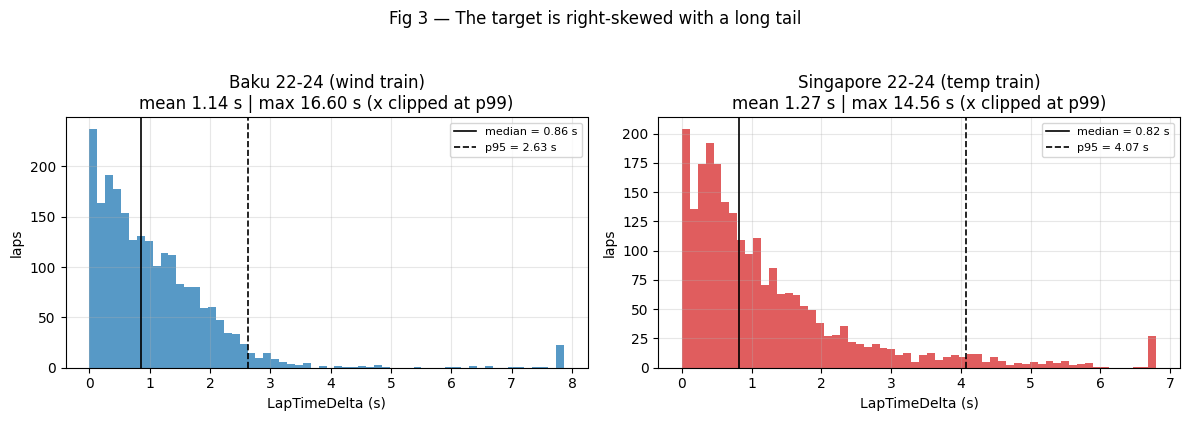

,count,mean,std,min,50%,90%,95%,99%,max
Baku 22-24 (wind train),2248.0,1.14,1.45,0.0,0.86,2.16,2.63,7.86,16.60
Baku 25 (wind in-domain),725.0,0.85,0.70,0.0,0.71,1.71,2.26,3.17,4.75
Jeddah 25 (wind cross),776.0,0.82,0.72,0.0,0.65,1.69,2.14,2.94,7.09
Singapore 22-24 (temp train),2366.0,1.27,1.50,0.0,0.82,2.84,4.07,6.80,14.56
Singapore 25 (temp in-dom.),1080.0,1.26,2.13,0.0,0.74,2.57,3.63,12.57,34.36
Vegas 25 (temp cross),712.0,0.87,0.67,0.0,0.73,1.74,2.18,3.19,3.94


In [5]:
pairs = [("Baku 22-24 (wind train)", WIND_C), ("Singapore 22-24 (temp train)", TEMP_C)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, colour) in zip(axes, pairs):
    y = modelled[label]["y"]
    hi = y.quantile(0.99)
    ax.hist(y.clip(upper=hi), bins=60, color=colour, alpha=0.75)
    for q, style, name in [(0.5, "-", "median"), (0.95, "--", "p95")]:
        ax.axvline(y.quantile(q), color="black", ls=style, lw=1.2,
                   label=f"{name} = {y.quantile(q):.2f} s")
    ax.set_title(f"{label}\nmean {y.mean():.2f} s | max {y.max():.2f} s (x clipped at p99)")
    ax.set_xlabel("LapTimeDelta (s)")
    ax.set_ylabel("laps")
    ax.legend(fontsize=8)
fig.suptitle("Fig 3 — The target is right-skewed with a long tail", y=1.04)
plt.tight_layout()
plt.show()

pd.DataFrame({
    label: modelled[label]["y"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2)
    for label in RACES
}).T

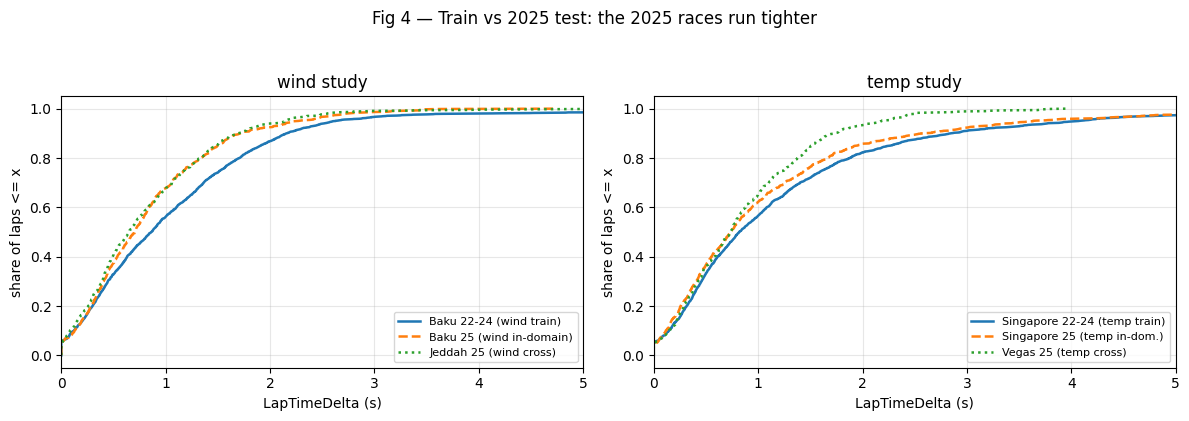

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
groups = [
    ("wind study", ["Baku 22-24 (wind train)", "Baku 25 (wind in-domain)", "Jeddah 25 (wind cross)"]),
    ("temp study", ["Singapore 22-24 (temp train)", "Singapore 25 (temp in-dom.)", "Vegas 25 (temp cross)"]),
]
for ax, (title, labels) in zip(axes, groups):
    for label, ls in zip(labels, ["-", "--", ":"]):
        y = np.sort(modelled[label]["y"].values)
        ax.plot(y, np.arange(1, len(y) + 1) / len(y), ls, lw=1.8, label=label)
    ax.set_xlim(0, 5)
    ax.set_xlabel("LapTimeDelta (s)")
    ax.set_ylabel("share of laps <= x")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Fig 4 — Train vs 2025 test: the 2025 races run tighter", y=1.04)
plt.tight_layout()
plt.show()

**Reading it.** Half of all laps sit within roughly 0.8-0.9 s of their stint best, while the extreme
tail reaches 16 s. Two consequences follow. First, the *typical* signal being modelled is
sub-second, so a mean absolute error near 0.45 s is a meaningful fraction of it and R² in the
0.2-0.4 band is what a well-behaved model looks like here — not evidence of a broken pipeline.

Second, every 2025 curve sits to the left of its training curve: median deltas fall from 0.86 s to
0.71 s at Baku and from 0.82 s to 0.74 s at Singapore, so within-stint spread genuinely narrowed. A
model fitted on 2022-24 will therefore predict larger deltas than 2025 delivers. *Why* it narrowed
is not something this data settles — tyre construction changes, fewer interruptions and race-specific
dynamics are all live candidates — so the honest handling is to measure the offset rather than
explain it: the evaluation step reports it as a median-residual bias correction and never retrains
on the test season.

## Q4 — Is there a degradation signal at all?

If tyre wear did not measurably slow laps down, the whole feature set would be theatre. Averaging
the target over in-stint position, split by compound, shows what the aggregate view actually
contains — which is not quite the textbook degradation ramp.

Baku 22-24 (wind train)
  stint-opening laps surviving the filter: 37 (1.6% of modelled data)
  all of them the race-start lap?         True  (pit-out laps were already filtered out)
  mean LapTimeDelta                       9.67 s vs 1.00 s on laps 2+
Singapore 22-24 (temp train)
  stint-opening laps surviving the filter: 20 (0.8% of modelled data)
  all of them the race-start lap?         True  (pit-out laps were already filtered out)
  mean LapTimeDelta                       9.51 s vs 1.20 s on laps 2+


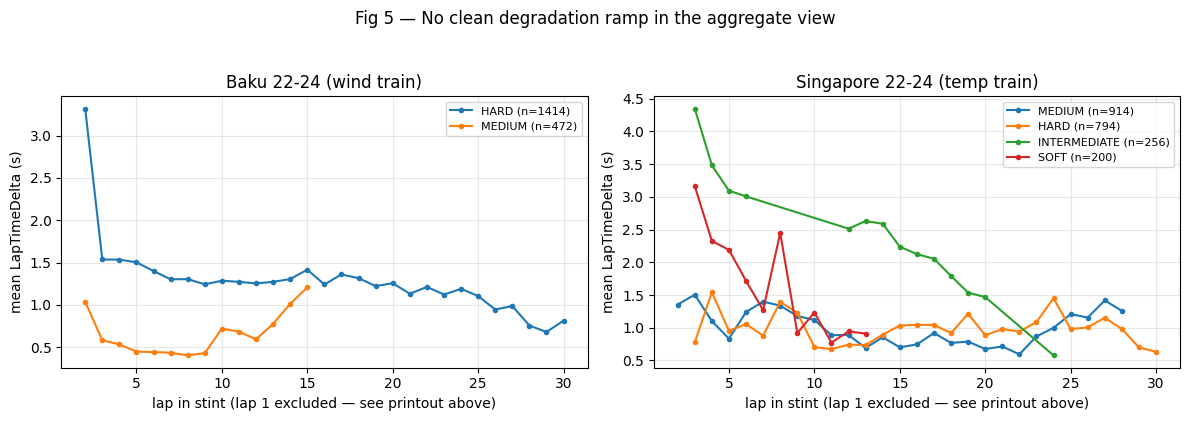

In [7]:
for label, _ in pairs:
    df = modelled[label]["df"]
    opening = df[df["LapInStint"] == 1]
    rest = df[df["LapInStint"] > 1]
    print(f"{label}")
    print(f"  stint-opening laps surviving the filter: {len(opening)} "
          f"({100 * len(opening) / len(df):.1f}% of modelled data)")
    print(f"  all of them the race-start lap?         {bool((opening['LapNumber'] == 1).all())}"
          f"  (pit-out laps were already filtered out)")
    print(f"  mean LapTimeDelta                       {opening['LapTimeDelta'].mean():.2f} s "
          f"vs {rest['LapTimeDelta'].mean():.2f} s on laps 2+")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, colour) in zip(axes, pairs):
    df = modelled[label]["df"]
    for compound in df["Compound"].value_counts().index:
        sub = df[(df["Compound"] == compound) & df["LapInStint"].between(2, 30)]
        if len(sub) < 80:
            continue
        curve = sub.groupby("LapInStint")["LapTimeDelta"].agg(["mean", "count"])
        curve = curve[curve["count"] >= 10]
        ax.plot(curve.index, curve["mean"], marker="o", ms=3, lw=1.5,
                label=f"{compound} (n={len(sub)})")
    ax.set_xlabel("lap in stint (lap 1 excluded — see printout above)")
    ax.set_ylabel("mean LapTimeDelta (s)")
    ax.set_title(label)
    ax.legend(fontsize=8)
fig.suptitle("Fig 5 — No clean degradation ramp in the aggregate view", y=1.04)
plt.tight_layout()
plt.show()

**Reading it — and this one contradicts the textbook expectation.** Two things stand out, neither of
them a tidy upward degradation slope.

First, the stint-opening laps that survive the filter are *exclusively race-start laps* — every one
of them is lap 1 of the race, because every other stint-opening lap is a pit-out lap the filter has
already removed. There are only 37 of them at Baku (1.6% of the modelled data) and 20 at Singapore
(0.8%), and they average 9.67 s and 9.51 s against roughly 1.0-1.2 s for every later lap. That is a
standing start from the grid, not tyre wear: a small, extreme sub-population that would distort any
average it entered, so the figure below excludes it.

Second, once that lap is removed the profile is essentially **flat** — a 0.5-1.5 s band with no
monotone ramp. This is partly a property of the target: because `LapTimeDelta` is re-based on each
stint's own fastest lap, a smooth within-stint trend is absorbed by construction, and averaging over
stints of different lengths flattens what remains. The compound ordering is not the expected
soft-worst ranking either. At Singapore the highest curve belongs to `INTERMEDIATE`, and it *falls*
from 4.3 s to 0.6 s as the stint progresses — a wet-weather tyre on a drying track, which is a
track-condition effect wearing a compound label rather than degradation.

The honest conclusion is that the degradation effect is real but **conditional**, not a marginal
trend a scatter plot can show. That is precisely the case for fitting tree ensembles, which can
represent it as an interaction, and then reading the effect back out with partial dependence while
holding the other features fixed — instead of trusting an aggregate curve like this one.

## Q5 — What conditions were actually observed?

This is the question that decides whether a model trained on one circuit can say anything about
another. The causal features are compared between each study's training data and its 2025 test
races, with the training support shaded.

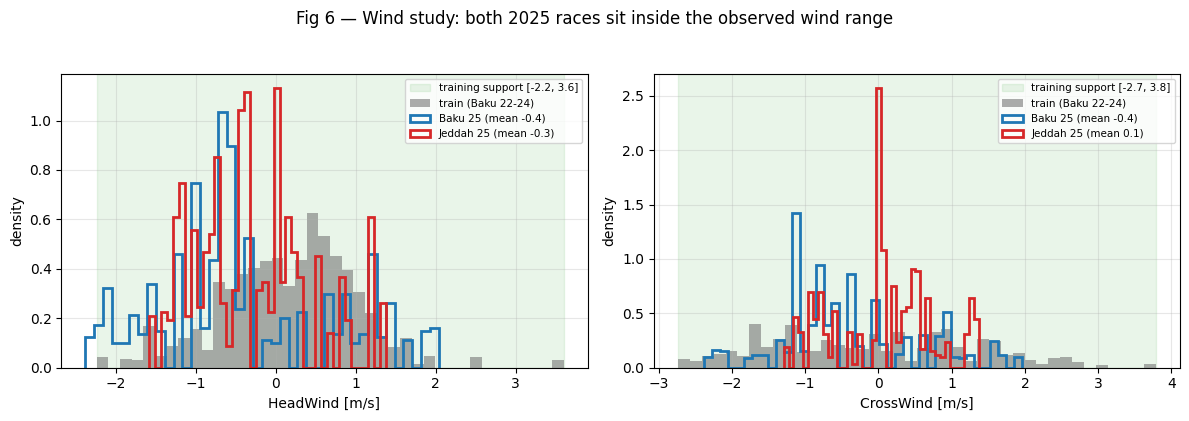

In [8]:
def support_panel(ax, feature, train_label, test_labels, unit):
    train = modelled[train_label]["x"][feature]
    lo, hi = train.min(), train.max()
    ax.axvspan(lo, hi, color="tab:green", alpha=0.10,
               label=f"training support [{lo:.1f}, {hi:.1f}]")
    ax.hist(train, bins=40, color="grey", alpha=0.65, density=True,
            label=f"train ({train_label.split(' (')[0]})")
    for test_label, colour in zip(test_labels, ["tab:blue", "tab:red"]):
        test = modelled[test_label]["x"][feature]
        ax.hist(test, bins=40, histtype="step", lw=2, color=colour, density=True,
                label=f"{test_label.split(' (')[0]} (mean {test.mean():.1f})")
    ax.set_xlabel(f"{feature} [{unit}]")
    ax.set_ylabel("density")
    ax.legend(fontsize=7.5)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["HeadWind", "CrossWind"]):
    support_panel(ax, feat, "Baku 22-24 (wind train)",
                  ["Baku 25 (wind in-domain)", "Jeddah 25 (wind cross)"], "m/s")
fig.suptitle("Fig 6 — Wind study: both 2025 races sit inside the observed wind range", y=1.04)
plt.tight_layout()
plt.show()

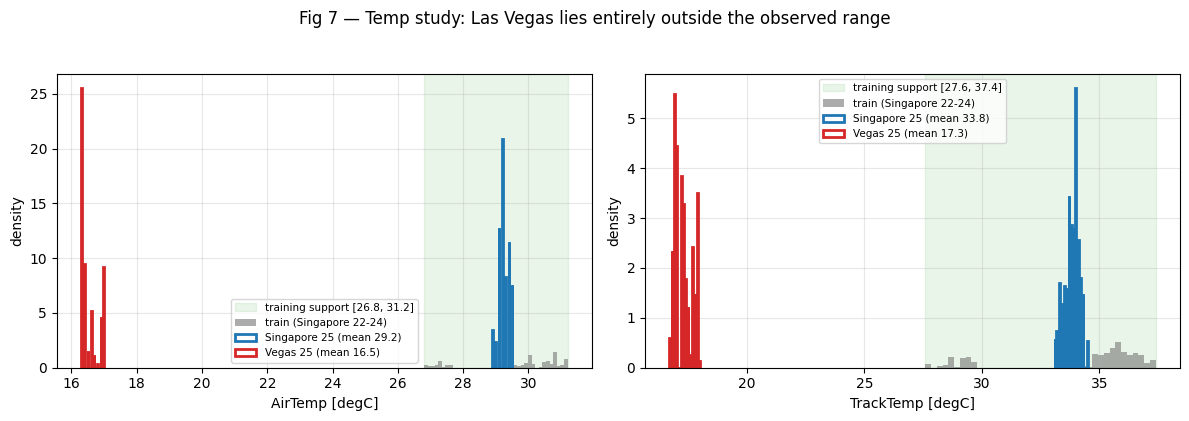

Singapore training TrackTemp support   : [27.60, 37.40] degC
Las Vegas 2025 TrackTemp              : [16.70, 18.00] degC  (mean 17.27)
Vegas laps inside the training support: 0.0%
gap: coldest training lap minus hottest Vegas lap = 9.60 degC


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["AirTemp", "TrackTemp"]):
    support_panel(ax, feat, "Singapore 22-24 (temp train)",
                  ["Singapore 25 (temp in-dom.)", "Vegas 25 (temp cross)"], "degC")
fig.suptitle("Fig 7 — Temp study: Las Vegas lies entirely outside the observed range", y=1.04)
plt.tight_layout()
plt.show()

tt_train = modelled["Singapore 22-24 (temp train)"]["x"]["TrackTemp"]
tt_vegas = modelled["Vegas 25 (temp cross)"]["x"]["TrackTemp"]
inside = ((tt_vegas >= tt_train.min()) & (tt_vegas <= tt_train.max())).mean()
print(f"Singapore training TrackTemp support   : [{tt_train.min():.2f}, {tt_train.max():.2f}] degC")
print(f"Las Vegas 2025 TrackTemp              : [{tt_vegas.min():.2f}, {tt_vegas.max():.2f}] degC"
      f"  (mean {tt_vegas.mean():.2f})")
print(f"Vegas laps inside the training support: {100 * inside:.1f}%")
print(f"gap: coldest training lap minus hottest Vegas lap = {tt_train.min() - tt_vegas.max():.2f} degC")

**Reading it — this is the headline, visible with no model involved.** In the wind study the 2025
races overlap the training distribution, so a model trained on Baku is being asked about conditions
it has seen. In the temperature study the overlap is *zero*: every Las Vegas lap is colder than the
coldest lap Singapore ever provided, by roughly ten degrees. Any temperature prediction there is
extrapolation by construction — which is why the strategy layer checks the training support and
withholds its correction rather than answering, and why the measured cross-domain R² of -6.08 was
the expected outcome rather than a surprise.

## Q6 — Are the control features confounded?

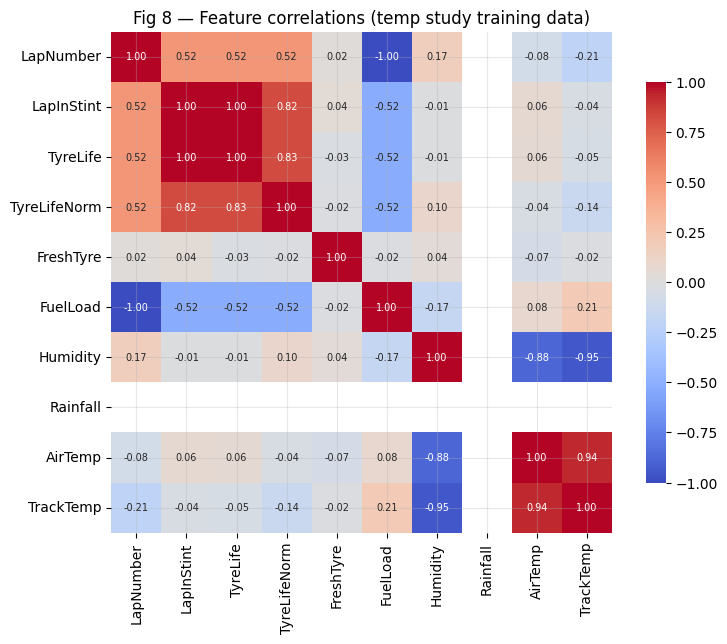

FuelLoad vs LapNumber : -1.0000  (deterministic by construction)
TyreLife vs LapInStint: +0.9964
AirTemp vs TrackTemp  : +0.9359


In [10]:
x = modelled["Singapore 22-24 (temp train)"]["x"]
numeric = [c for c in x.columns if not c.startswith("Compound_")]
corr = x[numeric].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Fig 8 — Feature correlations (temp study training data)")
plt.tight_layout()
plt.show()

print(f"FuelLoad vs LapNumber : {corr.loc['FuelLoad', 'LapNumber']:+.4f}  (deterministic by construction)")
print(f"TyreLife vs LapInStint: {corr.loc['TyreLife', 'LapInStint']:+.4f}")
print(f"AirTemp vs TrackTemp  : {corr.loc['AirTemp', 'TrackTemp']:+.4f}")

**Reading it.** `FuelLoad` is defined as `110 - LapNumber x 1.7`, so its correlation with
`LapNumber` is exactly -1: the two carry identical information and their importances must be read
jointly rather than as separate effects. The tyre-age features are strongly but not perfectly
correlated, which is the point of keeping all three — they disagree precisely where tyres are
inherited across stints. The two temperature axes also move together, so their individual
partial-dependence curves describe a shared warm-track regime rather than two independent knobs.

## Q7 — Is the data clean where it matters?

Missingness only matters in the columns the model consumes. It is also worth checking how finely
weather is really sampled, since every lap inherits the most recent weather reading.

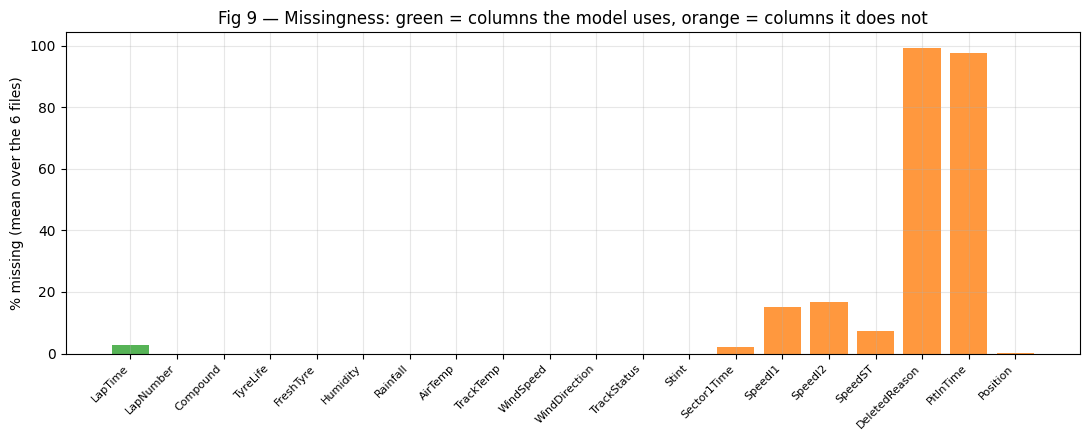

Highest missingness among the columns actually used:
LapTime      6.0
LapNumber    0.0
Compound     0.0


In [11]:
used = ["LapTime", "LapNumber", "Compound", "TyreLife", "FreshTyre", "Humidity",
        "Rainfall", "AirTemp", "TrackTemp", "WindSpeed", "WindDirection", "TrackStatus", "Stint"]
unused = ["Sector1Time", "SpeedI1", "SpeedI2", "SpeedST", "DeletedReason", "PitInTime", "Position"]

miss = pd.DataFrame({
    label: (df[used + unused].isna().mean() * 100).round(1) for label, df in raw.items()
})
mean_miss = miss.mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 4.5))
colours = ["tab:green"] * len(used) + ["tab:orange"] * len(unused)
ax.bar(range(len(mean_miss)), mean_miss.values, color=colours, alpha=0.8)
ax.set_xticks(range(len(mean_miss)))
ax.set_xticklabels(mean_miss.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% missing (mean over the 6 files)")
ax.set_title("Fig 9 — Missingness: green = columns the model uses, orange = columns it does not")
plt.tight_layout()
plt.show()

print("Highest missingness among the columns actually used:")
print(miss.loc[used].max(axis=1).sort_values(ascending=False).head(3).to_string())

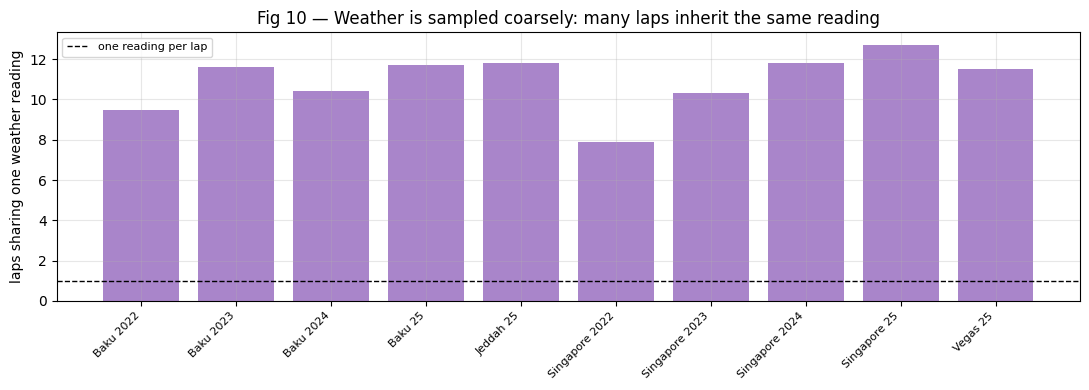

,laps,distinct weather rows,laps per weather reading
race,,,
Baku 2022,891,94,9.5
Baku 2023,962,83,11.6
Baku 2024,973,94,10.4
Baku 25,968,83,11.7
Jeddah 25,898,76,11.8
Singapore 2022,945,119,7.9
Singapore 2023,1088,106,10.3
Singapore 2024,1177,100,11.8
Singapore 25,1229,97,12.7


In [12]:
weather_cols = ["AirTemp", "TrackTemp", "Humidity", "Pressure", "WindSpeed", "WindDirection"]
rows = []
for label, df in raw.items():
    for year, grp in df.groupby("RaceYear"):
        name = f"{label.split(' (')[0]}" if "22-24" not in label else f"{label.split(' ')[0]} {year}"
        rows.append({
            "race": name,
            "laps": len(grp),
            "distinct weather rows": grp[weather_cols].drop_duplicates().shape[0],
        })
gran = pd.DataFrame(rows)
gran["laps per weather reading"] = (gran["laps"] / gran["distinct weather rows"]).round(1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(gran["race"], gran["laps per weather reading"], color="tab:purple", alpha=0.8)
ax.axhline(1, color="black", ls="--", lw=1, label="one reading per lap")
ax.set_ylabel("laps sharing one weather reading")
ax.set_xticks(range(len(gran)))
ax.set_xticklabels(gran["race"], rotation=45, ha="right", fontsize=8)
ax.set_title("Fig 10 — Weather is sampled coarsely: many laps inherit the same reading")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

gran.set_index("race")

**Reading it.** With one exception the columns the model consumes are complete, and the missingness
lives in columns that were excluded anyway (`DeletedReason` is empty except for deleted laps,
`PitInTime` only has a value on pit laps, `SpeedI2` is absent for an entire race). The exception is
`LapTime` itself, missing on up to 6% of raw laps — those rows cannot yield a target and are dropped
by the target step, which is the "other" column in the Q1 attrition table. Weather, however, is sampled
per minute rather than per lap, so several laps in the same window share one reading. That
coarseness limits how much *within-race* weather variation the models can exploit, and it is part of
why the studies are framed around differences in conditions between sessions rather than
lap-to-lap ones.

## What this changed about the modelling

Four findings from the above fed directly into decisions documented in
[methodology.md](../docs/methodology.md):

1. **The target's heavy tail sets the accuracy ceiling.** With a median around 0.85 s and a maximum
   near 16 s, sub-second mean absolute error and R² in the 0.2-0.4 range are the realistic
   operating point — so model selection weighs cross-domain behaviour and stability, not headline
   R² alone.
2. **Sector times and speed traps are leakage, proven not assumed.** The sector sum reproduces lap
   time to the millisecond, so a tempting "free accuracy" feature group is excluded on principle.
3. **The out-of-distribution failure was predictable from the data.** Las Vegas shares no
   temperature overlap with Singapore, so the support check in the strategy layer — refusing to
   correct rather than extrapolating — is a design response to a fact visible before any model ran.
4. **Some features are duplicates by construction.** `FuelLoad` is a deterministic function of
   `LapNumber` (r = -1), so their importances are interpreted jointly, and the three tyre-age
   features are kept precisely because they disagree in the inherited-tyre cases.
5. **The tyre effect is conditional, not a marginal trend.** The aggregate in-stint profile is flat
   once the stint's opening lap is separated out, so the mechanism has to be recovered by a model
   that can represent interactions and then read back with partial dependence — which is the shape
   of the whole modelling approach, chosen because of what this figure does *not* show.

Next: [`02_walkthrough.ipynb`](02_walkthrough.ipynb) picks up from here with the trained models —
evaluation across the four 2025 conditions, the mechanism curves, and the two undercut scenarios.